# Employee Attrition — Exploratory Data Analysis

**Dataset:** IBM HR Analytics Employee Attrition & Performance (1,470 employees × 35 features)

**Goal:** Identify the statistical and behavioral patterns that separate employees who leave from employees who stay, using descriptive statistics (mean, median, mode, variance, standard deviation) and distribution analysis across every feature in the dataset.

**Structure**
1. Data Loading & Quality Audit
2. Descriptive Statistics — All Numeric Features
3. Univariate Distributions — All Numeric Features
4. Outlier Audit (IQR method)
5. Categorical Feature Profile
6. Attrition Rate — Every Categorical / Ordinal Feature
7. Attrition vs. Every Continuous Feature
8. Correlation Structure
9. Multivariate Deep Dives
10. Key Findings & Recommendations


## 1. Data Loading & Quality Audit

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', None)

df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Shape: 1470 rows x 35 columns


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [3]:
quality_report = pd.DataFrame({
    'dtype': df.dtypes,
    'missing': df.isnull().sum(),
    'missing_pct': (df.isnull().sum() / len(df) * 100).round(2),
    'unique_values': df.nunique()
})
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate EmployeeNumbers: {df['EmployeeNumber'].duplicated().sum()}")
quality_report

Duplicate rows: 0
Duplicate EmployeeNumbers: 0


,dtype,missing,missing_pct,unique_values
Age,int64,0,0.0,43
Attrition,str,0,0.0,2
BusinessTravel,str,0,0.0,3
DailyRate,int64,0,0.0,886
Department,str,0,0.0,3
DistanceFromHome,int64,0,0.0,29
Education,int64,0,0.0,5
EducationField,str,0,0.0,6
EmployeeCount,int64,0,0.0,1
EmployeeNumber,int64,0,0.0,1470


**Audit result:** 0 missing values, 0 duplicate rows, 0 duplicate employee IDs — the dataset is fully clean. Three columns have exactly 1 unique value (`EmployeeCount`, `Over18`, `StandardHours`) and carry zero analytical signal; `EmployeeNumber` is a pure identifier. All four are excluded from analysis below.

In [4]:
ID_COLS = ['EmployeeNumber']
ZERO_VARIANCE_COLS = ['EmployeeCount', 'Over18', 'StandardHours']
df = df.drop(columns=ID_COLS + ZERO_VARIANCE_COLS)

# Binary flag used throughout for correlation / grouping
df['Attrition_Flag'] = (df['Attrition'] == 'Yes').astype(int)

CONTINUOUS = ['Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate', 'MonthlyIncome',
              'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'TotalWorkingYears',
              'TrainingTimesLastYear', 'YearsAtCompany', 'YearsInCurrentRole',
              'YearsSinceLastPromotion', 'YearsWithCurrManager']

ORDINAL = ['Education', 'EnvironmentSatisfaction', 'JobInvolvement', 'JobLevel',
           'JobSatisfaction', 'PerformanceRating', 'RelationshipSatisfaction',
           'StockOptionLevel', 'WorkLifeBalance']

CATEGORICAL = ['BusinessTravel', 'Department', 'EducationField', 'Gender',
               'JobRole', 'MaritalStatus', 'OverTime']

print(f"Continuous: {len(CONTINUOUS)} | Ordinal: {len(ORDINAL)} | Categorical: {len(CATEGORICAL)}")
print(f"Total analyzable features: {len(CONTINUOUS) + len(ORDINAL) + len(CATEGORICAL)}")

Continuous: 14 | Ordinal: 9 | Categorical: 7
Total analyzable features: 30


## 2. Descriptive Statistics — All Numeric Features

Mean, median, mode, variance, standard deviation, skewness and kurtosis for **every** continuous and ordinal feature — not just a selected subset — so no distributional pattern in the dataset is missed.

In [5]:
def full_descriptive_stats(columns):
    stats_df = pd.DataFrame({
        'Mean': df[columns].mean(),
        'Median': df[columns].median(),
        'Mode': df[columns].mode().iloc[0],
        'Variance': df[columns].var(),
        'Std Dev': df[columns].std(),
        'Skewness': df[columns].skew(),
        'Kurtosis': df[columns].kurt(),
        'Min': df[columns].min(),
        'Max': df[columns].max(),
        'Range': df[columns].max() - df[columns].min()
    }).round(2)
    return stats_df.sort_values('Skewness', ascending=False)

continuous_stats = full_descriptive_stats(CONTINUOUS)
continuous_stats

,Mean,Median,Mode,Variance,Std Dev,Skewness,Kurtosis,Min,Max,Range
YearsSinceLastPromotion,2.19,1.0,0.0,10.38,3.22,1.98,3.61,0,15,15
YearsAtCompany,7.01,5.0,5.0,37.53,6.13,1.76,3.94,0,40,40
MonthlyIncome,6502.93,4919.0,2342.0,22164857.07,4707.96,1.37,1.01,1009,19999,18990
TotalWorkingYears,11.28,10.0,10.0,60.54,7.78,1.12,0.92,0,40,40
NumCompaniesWorked,2.69,2.0,1.0,6.24,2.50,1.03,0.01,0,9,9
DistanceFromHome,9.19,7.0,2.0,65.72,8.11,0.96,-0.22,1,29,28
YearsInCurrentRole,4.23,3.0,2.0,13.13,3.62,0.92,0.48,0,18,18
YearsWithCurrManager,4.12,3.0,2.0,12.73,3.57,0.83,0.17,0,17,17
PercentSalaryHike,15.21,14.0,11.0,13.40,3.66,0.82,-0.30,11,25,14
TrainingTimesLastYear,2.80,3.0,2.0,1.66,1.29,0.55,0.49,0,6,6


**Reading the skew column:** values above ~1 indicate strong right-skew (a long tail of high values pulling the mean above the median). `YearsSinceLastPromotion`, `MonthlyIncome`, `YearsAtCompany`, and `TotalWorkingYears` are the most skewed — for these, the **median** is the more representative "typical employee" figure than the mean. `Age`, `DailyRate`, `HourlyRate`, and `MonthlyRate` are close to symmetric (skew near 0), consistent with them being closer to uniformly/randomly distributed in this dataset.

In [6]:
ordinal_stats = full_descriptive_stats(ORDINAL)
ordinal_stats

,Mean,Median,Mode,Variance,Std Dev,Skewness,Kurtosis,Min,Max,Range
PerformanceRating,3.15,3.0,3,0.13,0.36,1.92,1.70,3,4,1
JobLevel,2.06,2.0,1,1.23,1.11,1.03,0.40,1,5,4
StockOptionLevel,0.79,1.0,0,0.73,0.85,0.97,0.36,0,3,3
Education,2.91,3.0,3,1.05,1.02,-0.29,-0.56,1,5,4
RelationshipSatisfaction,2.71,3.0,3,1.17,1.08,-0.30,-1.18,1,4,3
EnvironmentSatisfaction,2.72,3.0,3,1.19,1.09,-0.32,-1.20,1,4,3
JobSatisfaction,2.73,3.0,4,1.22,1.10,-0.33,-1.22,1,4,3
JobInvolvement,2.73,3.0,3,0.51,0.71,-0.50,0.27,1,4,3
WorkLifeBalance,2.76,3.0,3,0.50,0.71,-0.55,0.42,1,4,3


**Insight:** Ordinal (survey-style) features mostly center around 3 on their 1–4/1–5 scales, i.e. the average employee reports being reasonably satisfied — which makes the *low-satisfaction minority* explored in Section 6 more meaningful, since they are a genuine minority pulling attrition risk up rather than the norm.

## 3. Univariate Distributions — All Continuous Features

Histogram + KDE for every continuous feature, mean and median marked, so the true shape of every distribution is visible (not just a hand-picked few).

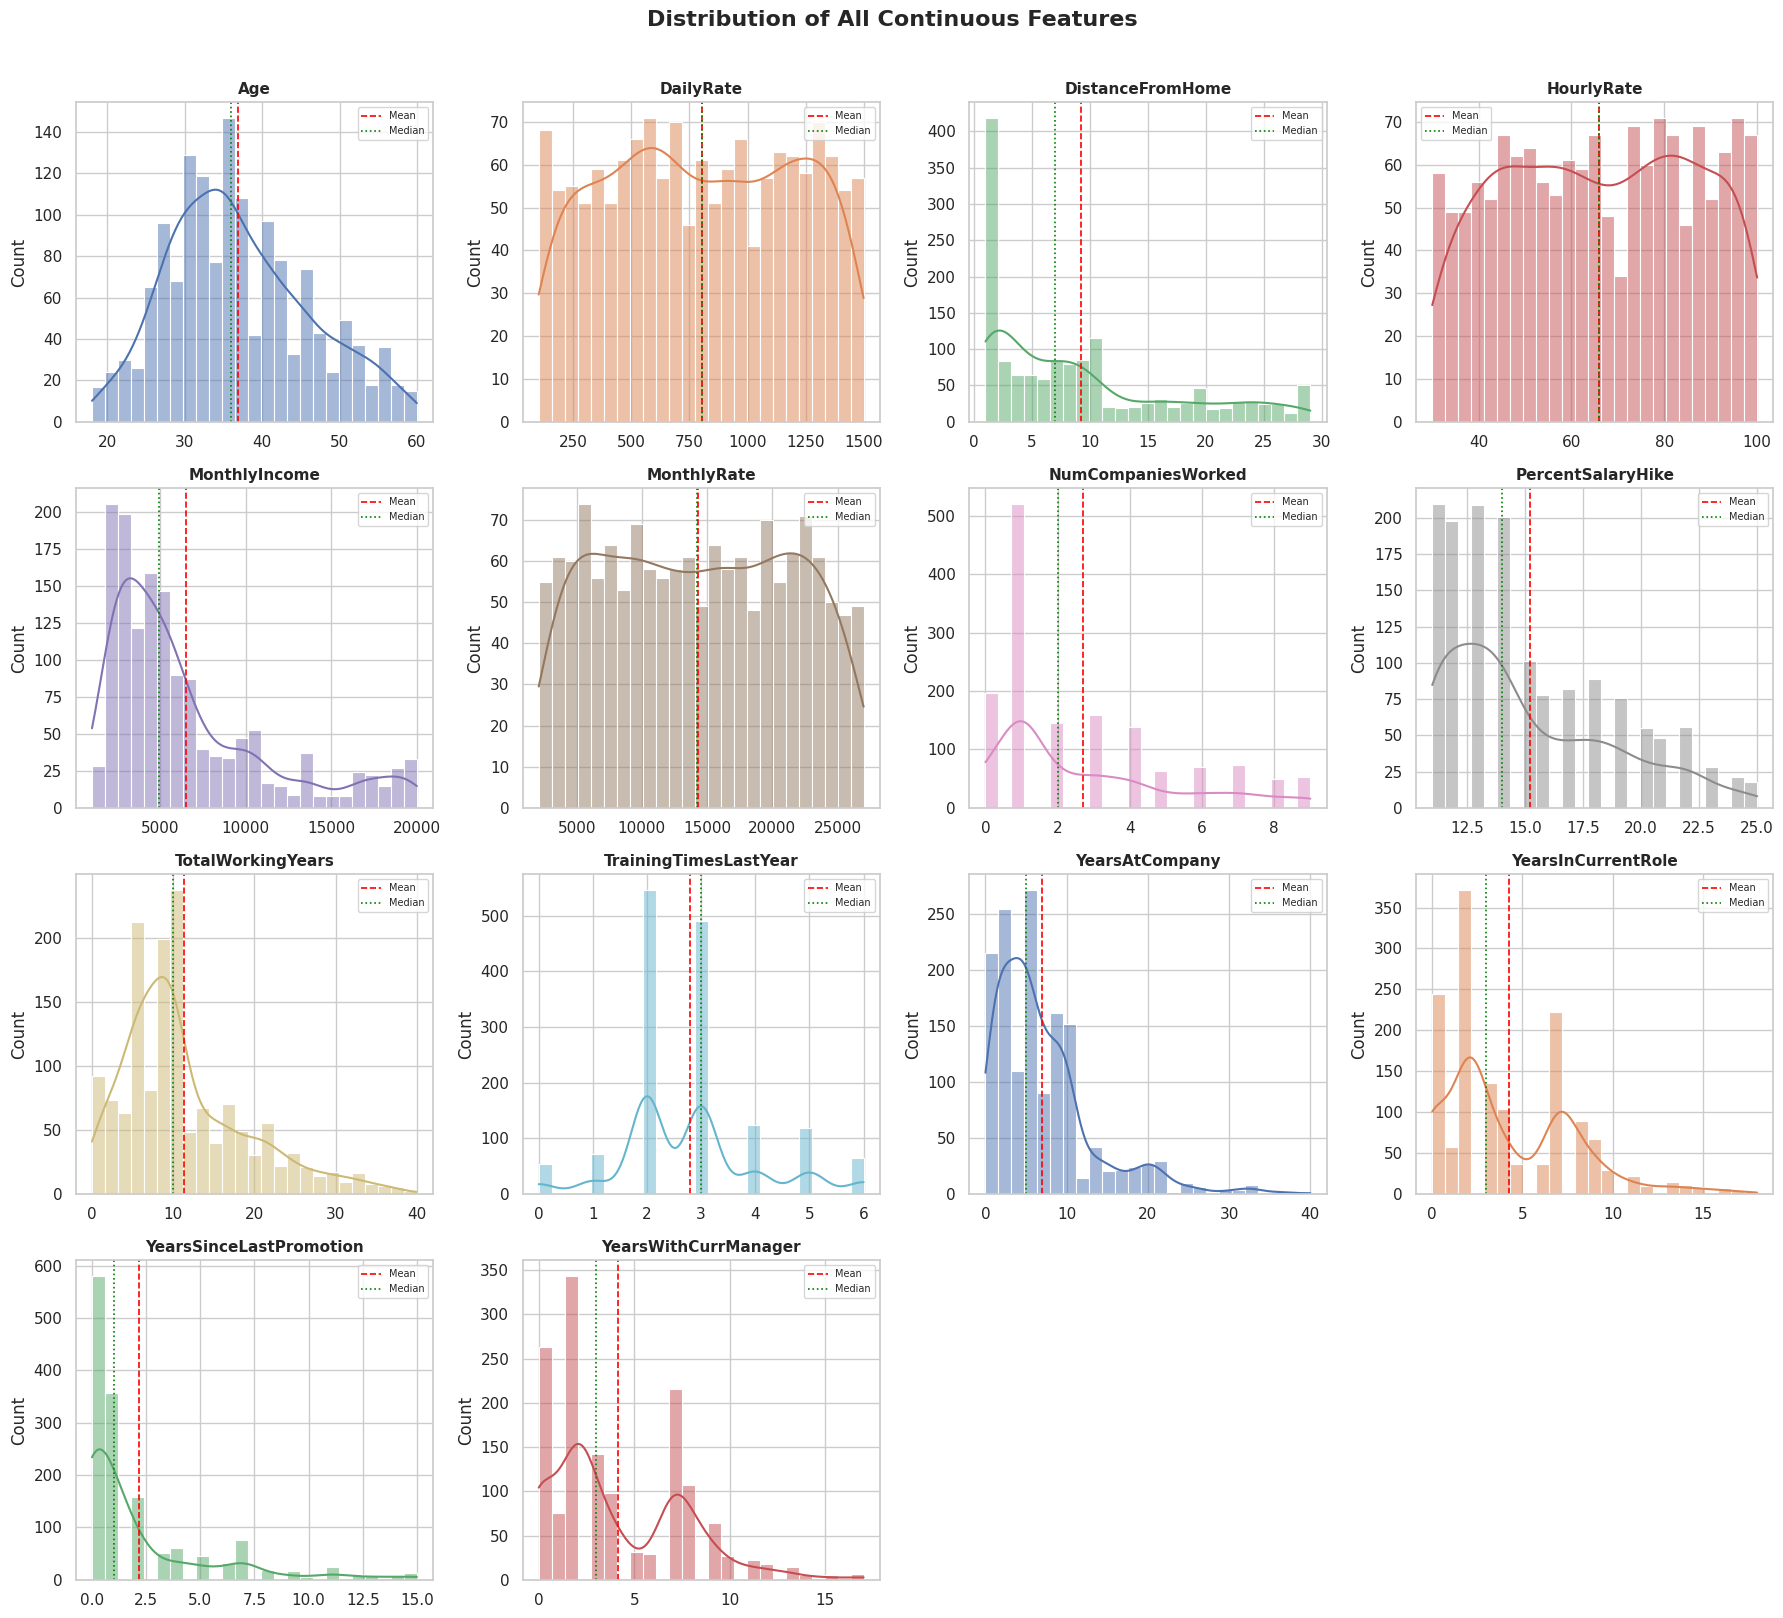

In [7]:
fig, axes = plt.subplots(4, 4, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(CONTINUOUS):
    ax = axes[i]
    sns.histplot(df[col], kde=True, ax=ax, color=sns.color_palette('deep')[i % 10], bins=25)
    ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.2, label='Mean')
    ax.axvline(df[col].median(), color='green', linestyle=':', linewidth=1.2, label='Median')
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.legend(fontsize=7)

for j in range(len(CONTINUOUS), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Distribution of All Continuous Features', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Insight:** Several career-tenure features (`YearsAtCompany`, `YearsInCurrentRole`, `YearsSinceLastPromotion`, `YearsWithCurrManager`, `TotalWorkingYears`) share the same right-skewed shape — the workforce is dominated by early/mid-career employees with a thinning tail of long-tenured veterans. `MonthlyIncome` shows the same pattern for the same underlying reason (income rises with tenure/level). In contrast, `DailyRate`, `HourlyRate`, and `MonthlyRate` look almost uniformly distributed rather than normal — a detail easy to miss if only "important-looking" columns are plotted.

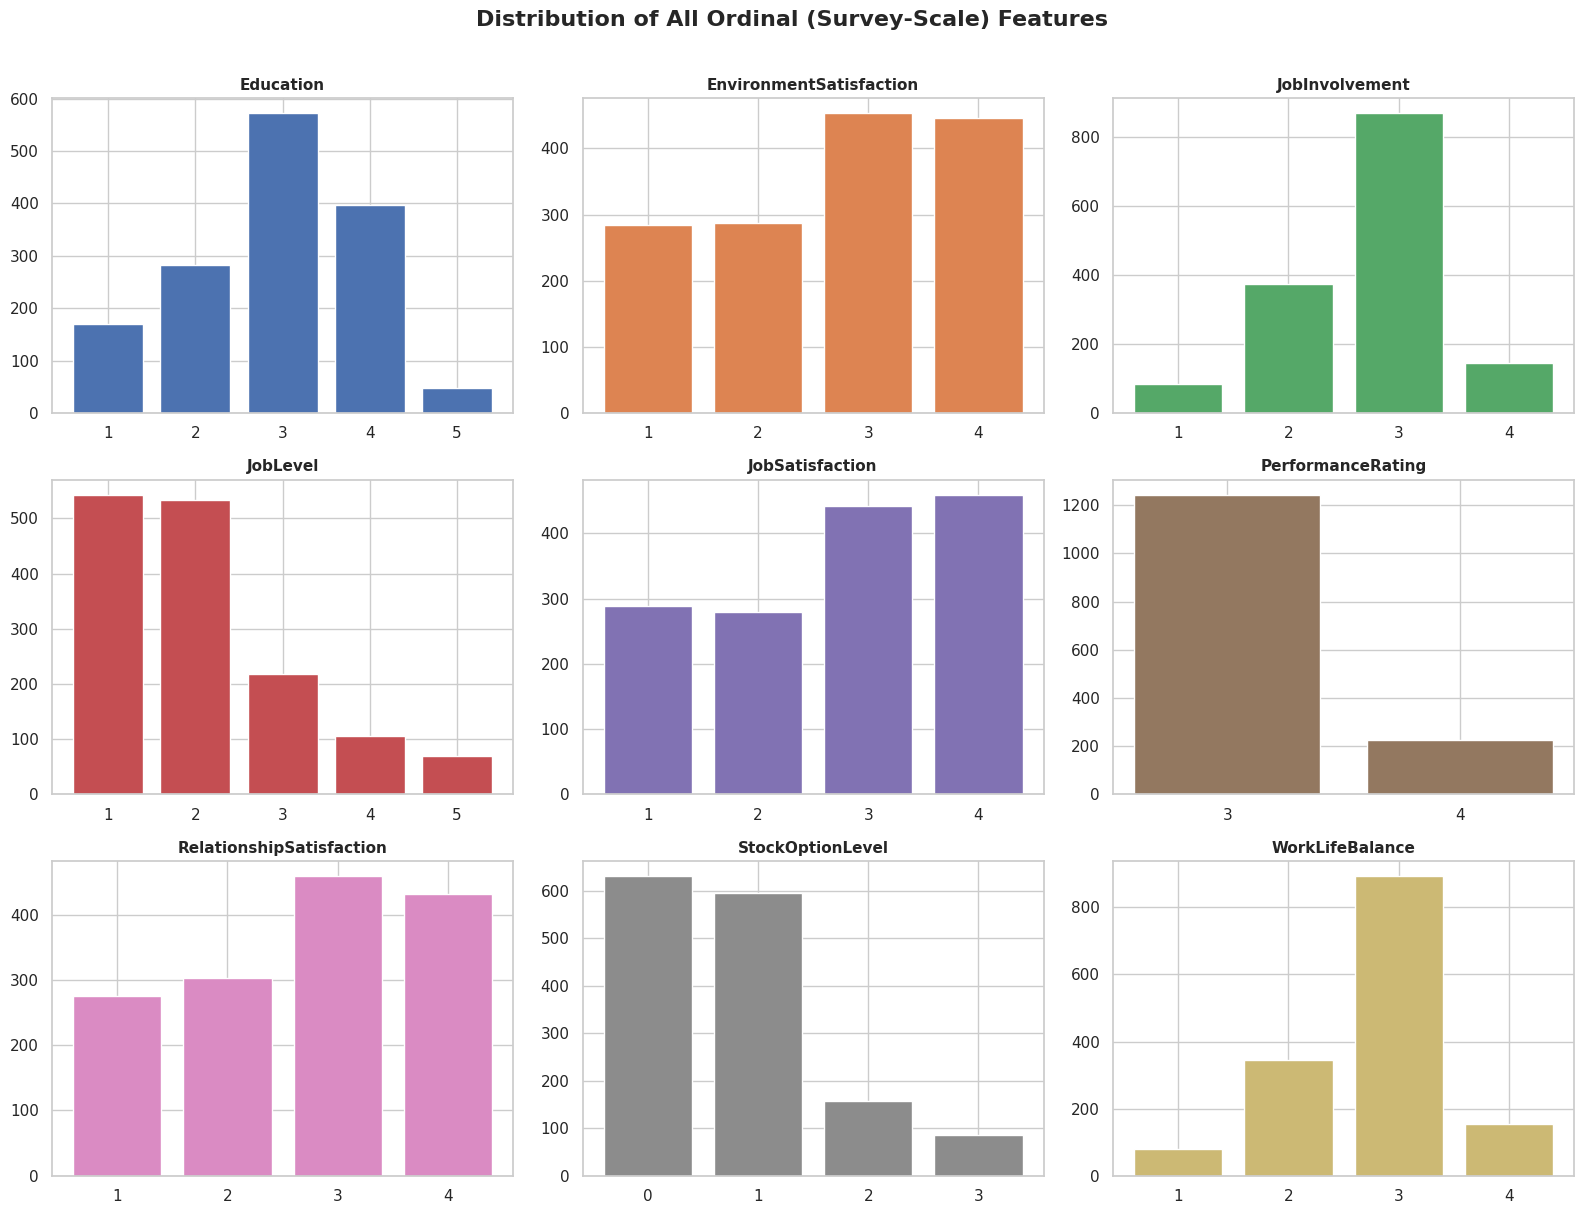

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(ORDINAL):
    ax = axes[i]
    counts = df[col].value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values, color=sns.color_palette('deep')[i % 10])
    ax.set_title(col, fontsize=11, fontweight='bold')

for j in range(len(ORDINAL), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Distribution of All Ordinal (Survey-Scale) Features', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Insight:** `PerformanceRating` only takes two values (3 and 4) in this dataset — nobody is rated 1 or 2, meaning this column has almost no discriminating power on its own and is unlikely to explain attrition. `StockOptionLevel` is heavily concentrated at 0–1, meaning most employees have little to no equity stake — worth flagging as a potential retention lever.

## 4. Outlier Audit — IQR Method (All Continuous Features)

Using the standard IQR rule (values beyond Q1 − 1.5×IQR or Q3 + 1.5×IQR) applied systematically to every continuous column, rather than eyeballing a handful of boxplots.

In [9]:
def iqr_outlier_count(col):
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    return pd.Series({'Q1': q1, 'Q3': q3, 'IQR': iqr, 'Lower Bound': lower,
                       'Upper Bound': upper, 'Outlier Count': n_outliers,
                       'Outlier %': round(n_outliers / len(df) * 100, 2)})

outlier_report = pd.DataFrame({col: iqr_outlier_count(col) for col in CONTINUOUS}).T
outlier_report.sort_values('Outlier %', ascending=False)

,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
TrainingTimesLastYear,2.0,3.00,1.00,0.500,4.500,238.0,16.19
MonthlyIncome,2911.0,8379.00,5468.00,-5291.000,16581.000,114.0,7.76
YearsSinceLastPromotion,0.0,3.00,3.00,-4.500,7.500,107.0,7.28
YearsAtCompany,3.0,9.00,6.00,-6.000,18.000,104.0,7.07
TotalWorkingYears,6.0,15.00,9.00,-7.500,28.500,63.0,4.29
NumCompaniesWorked,1.0,4.00,3.00,-3.500,8.500,52.0,3.54
YearsInCurrentRole,2.0,7.00,5.00,-5.500,14.500,21.0,1.43
YearsWithCurrManager,2.0,7.00,5.00,-5.500,14.500,14.0,0.95
MonthlyRate,8047.0,20461.50,12414.50,-10574.750,39083.250,0.0,0.00
DailyRate,465.0,1157.00,692.00,-573.000,2195.000,0.0,0.00


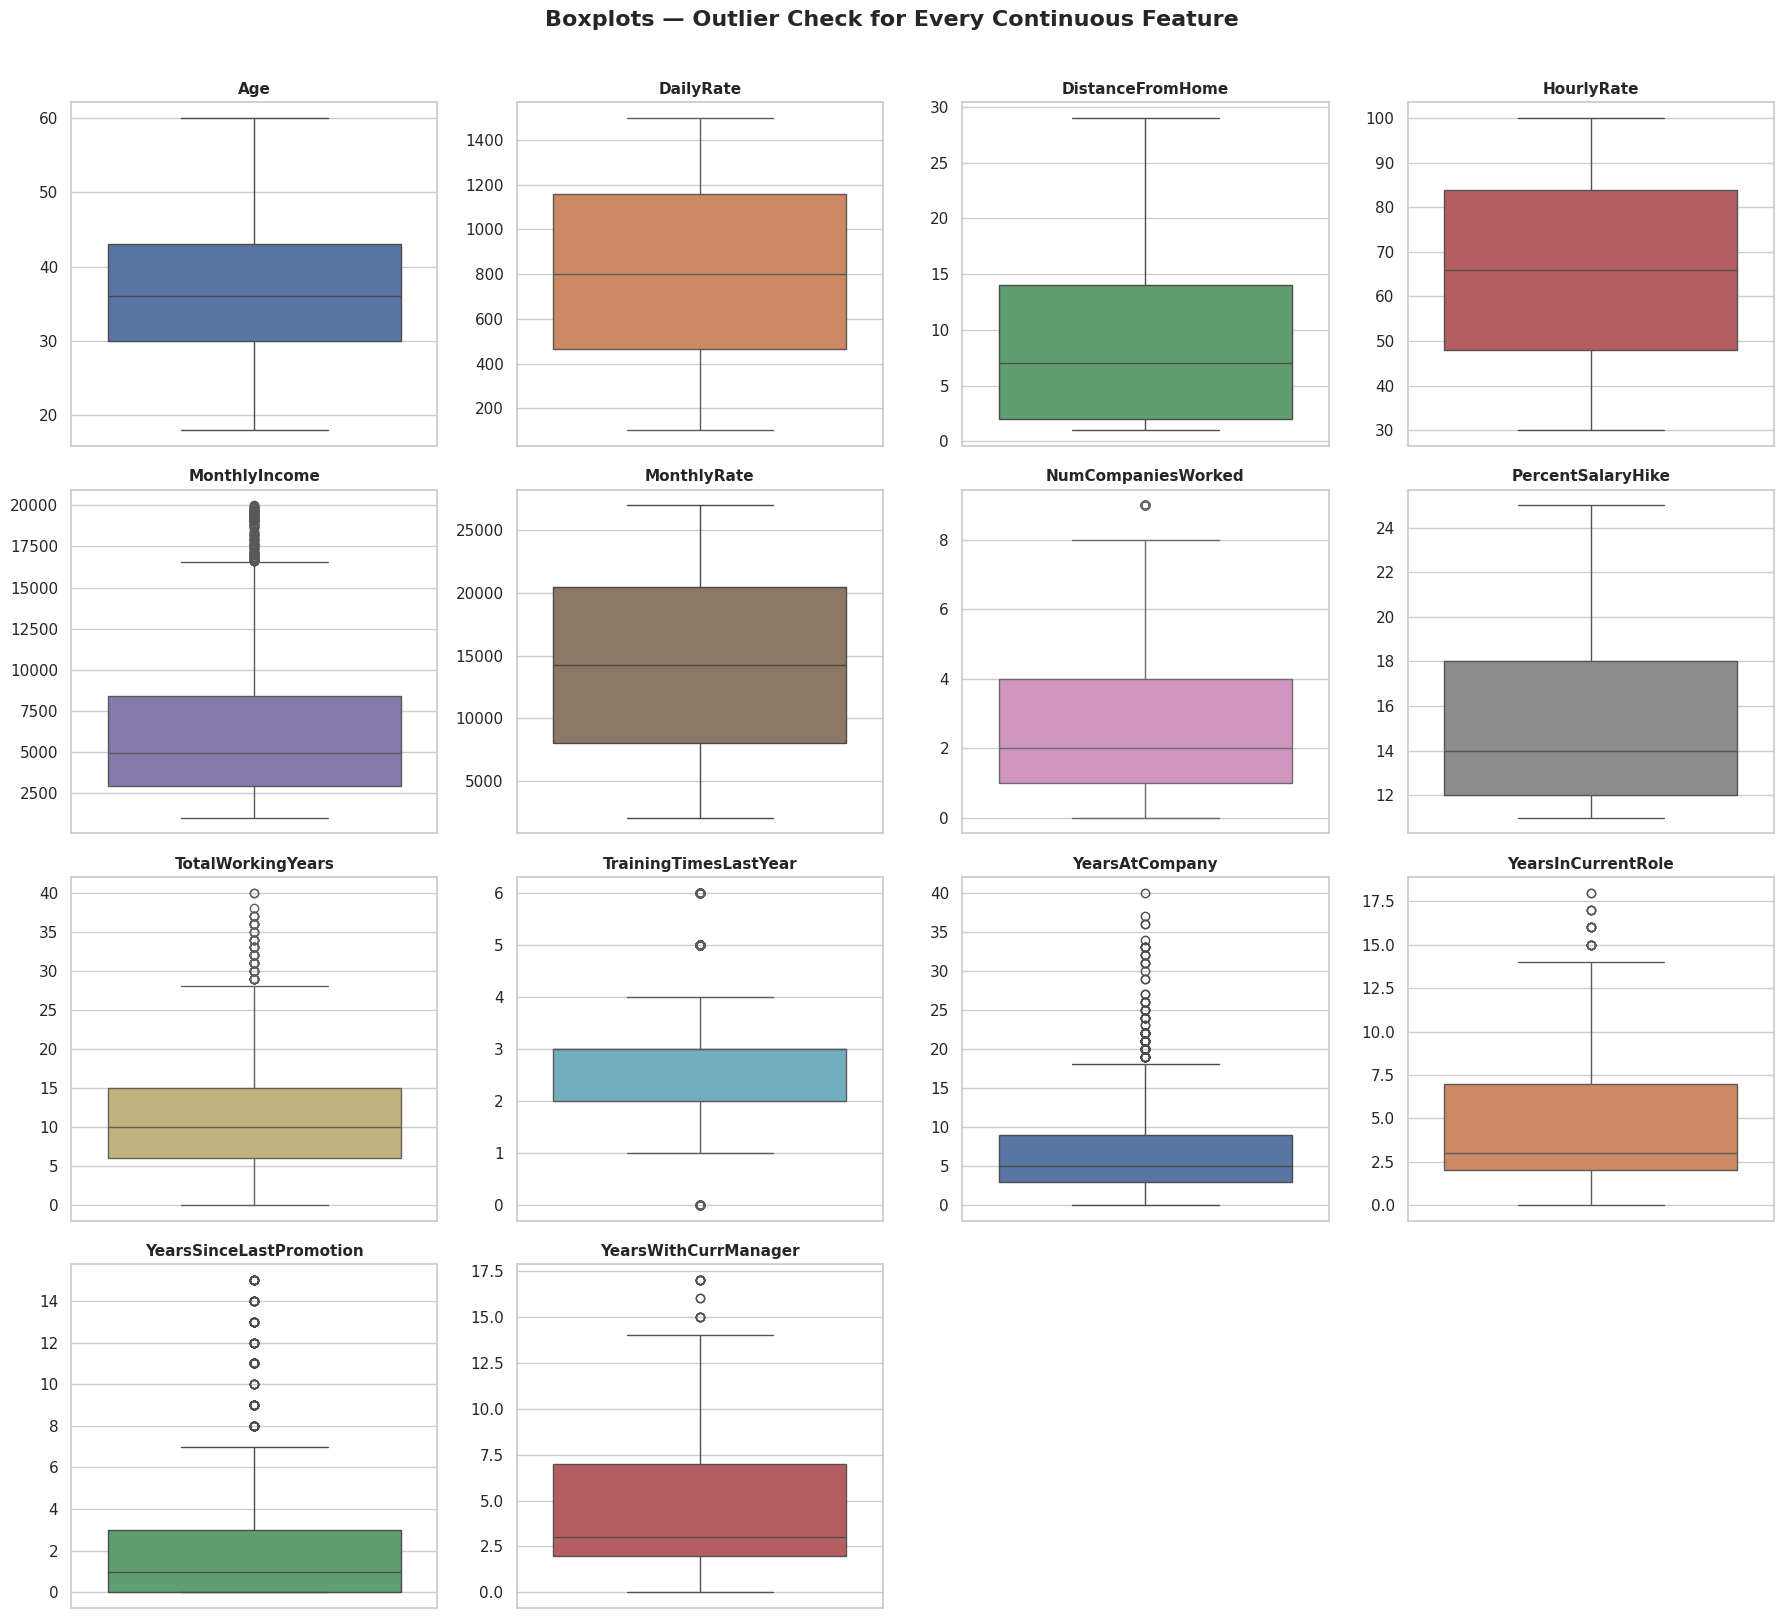

In [10]:
fig, axes = plt.subplots(4, 4, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(CONTINUOUS):
    ax = axes[i]
    sns.boxplot(y=df[col], ax=ax, color=sns.color_palette('deep')[i % 10])
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_ylabel('')

for j in range(len(CONTINUOUS), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Boxplots — Outlier Check for Every Continuous Feature', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Insight:** `YearsSinceLastPromotion`, `TotalWorkingYears`, `MonthlyIncome`, `YearsAtCompany`, `NumCompaniesWorked`, and `TrainingTimesLastYear` all show a meaningful percentage of statistical outliers. Every one of these is a *legitimate* extreme (senior employee, long tenure, high earner) rather than a data-entry error — so none are removed. They're kept, but flagged, since they can pull mean-based summaries away from what a "typical" employee looks like.

## 5. Categorical Feature Profile

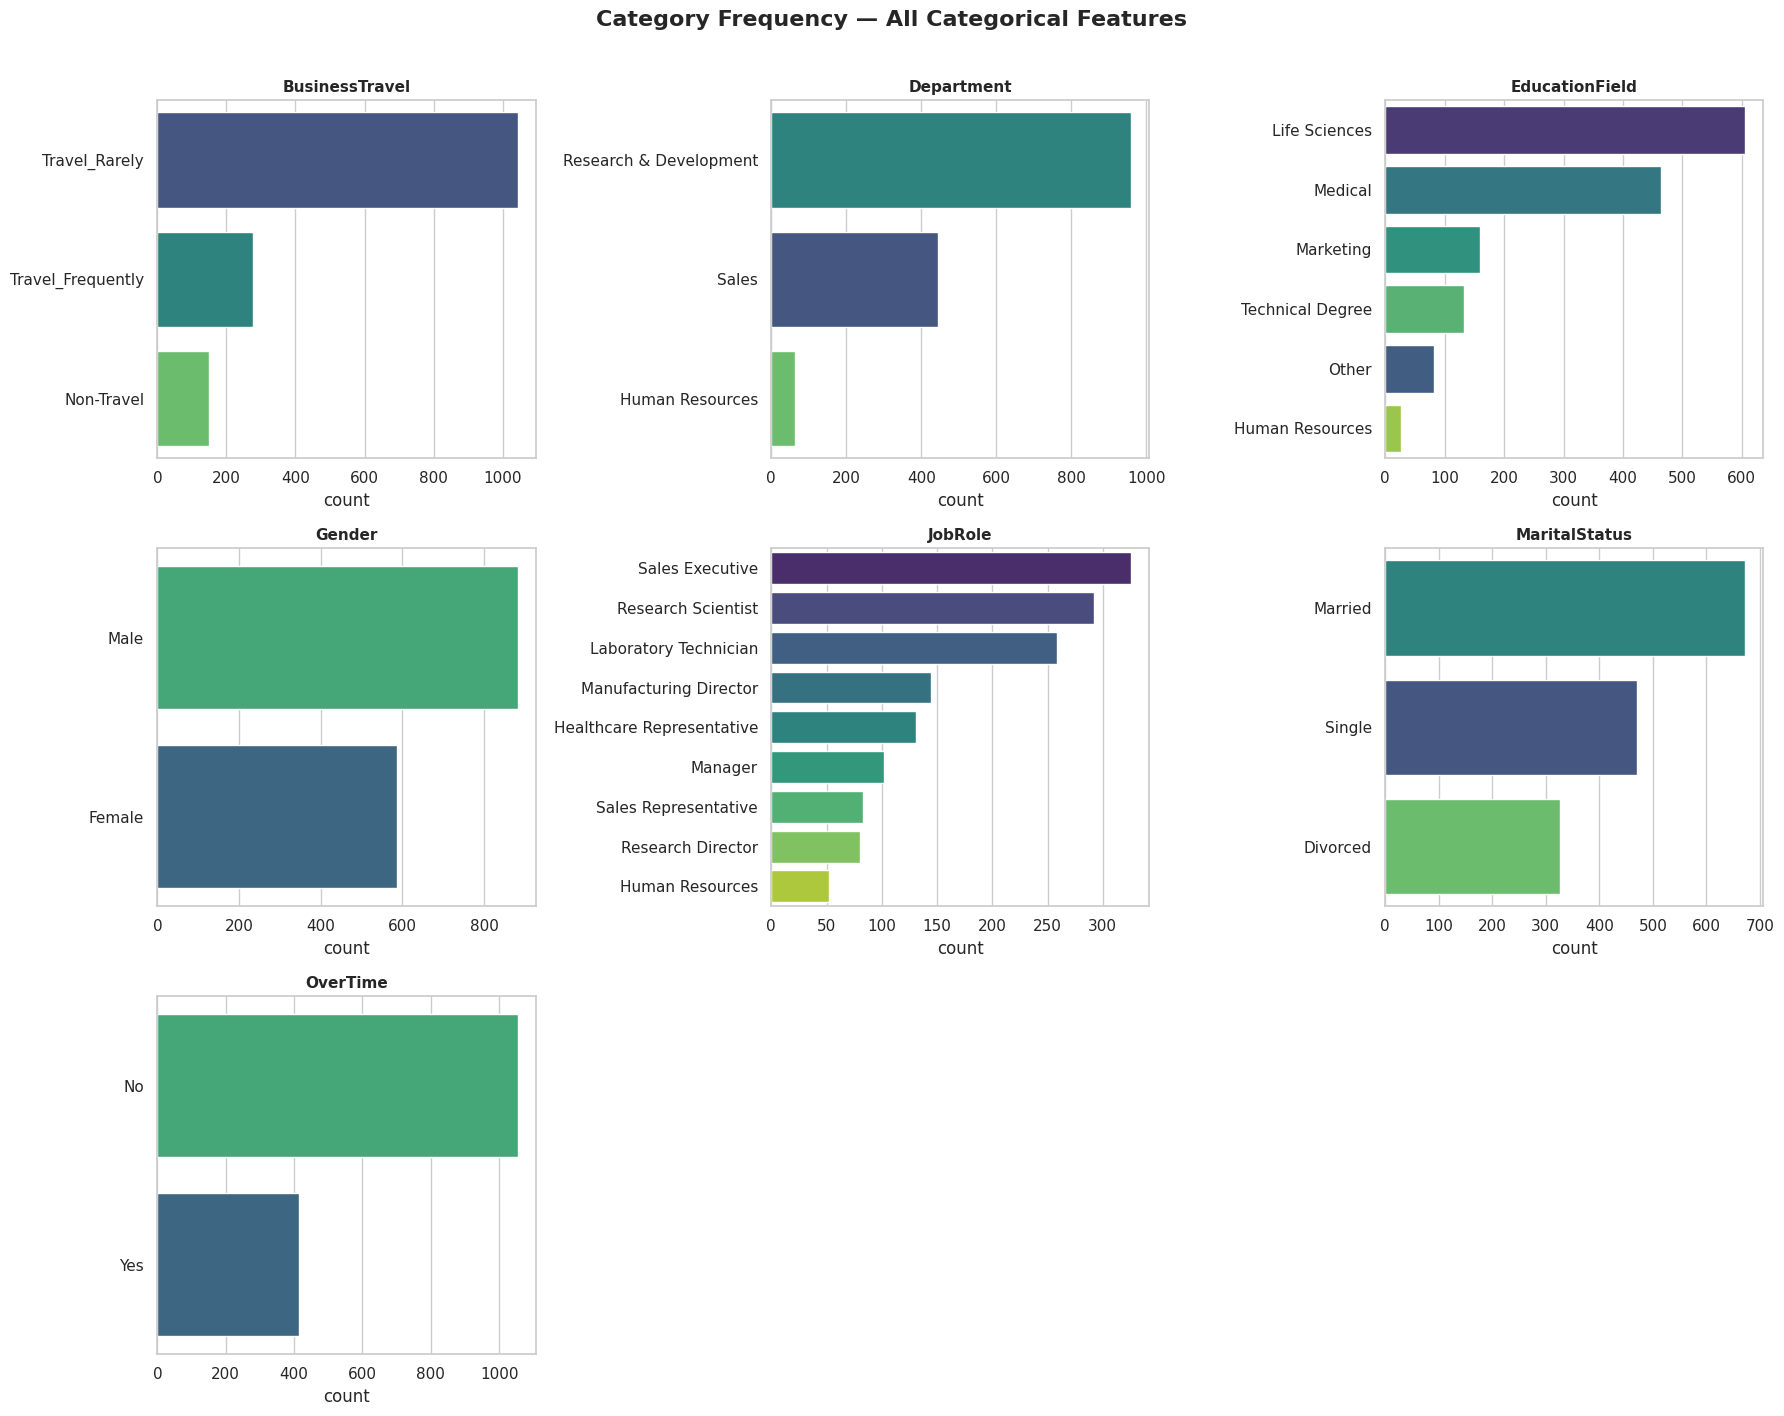

In [11]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(CATEGORICAL):
    ax = axes[i]
    order = df[col].value_counts().index
    sns.countplot(y=df[col], order=order, ax=ax, hue=df[col], legend=False,
                  palette='viridis')
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_ylabel('')

fig.delaxes(axes[7])
fig.delaxes(axes[8])
fig.suptitle('Category Frequency — All Categorical Features', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Insight:** Research & Development dominates headcount (~65%), most employees travel rarely, education is heavily concentrated in Life Sciences and Medical fields, and roughly 1 in 4 employees work overtime — this last figure matters a lot given how strongly OverTime correlates with attrition (Section 6).

## 6. Attrition Rate — Every Categorical & Ordinal Feature (vs. company baseline)

In [12]:
baseline = df['Attrition_Flag'].mean() * 100
print(f"Company-wide attrition baseline: {baseline:.2f}%")

def attrition_rate_by(col):
    return df.groupby(col, observed=True)['Attrition_Flag'].mean().mul(100).round(2).sort_values(ascending=False)

Company-wide attrition baseline: 16.12%


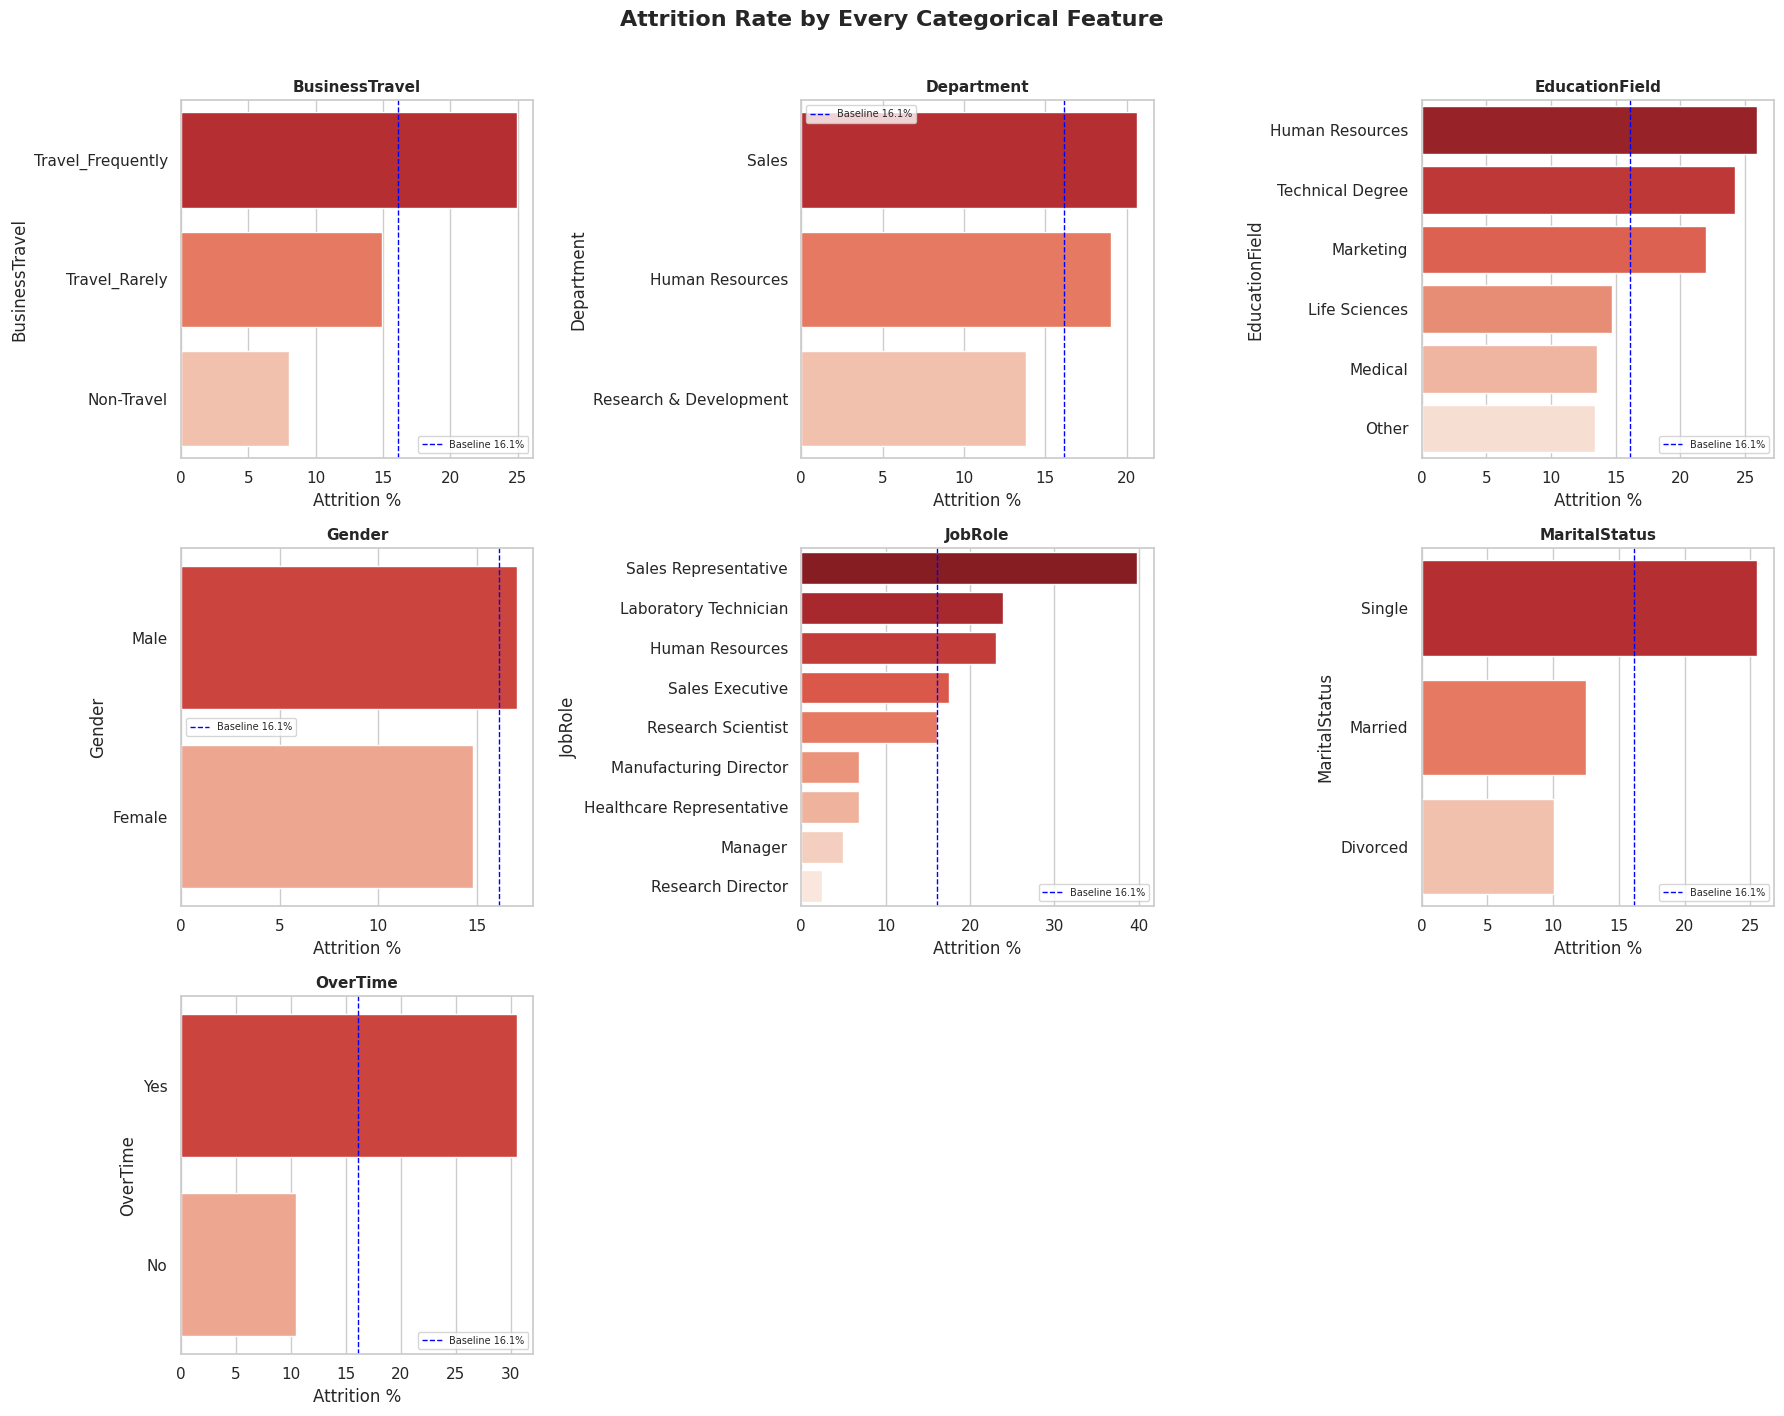

In [13]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(CATEGORICAL):
    ax = axes[i]
    rate = attrition_rate_by(col)
    sns.barplot(x=rate.values, y=rate.index, ax=ax, hue=rate.index, legend=False, palette='Reds_r')
    ax.axvline(baseline, color='blue', linestyle='--', linewidth=1, label=f'Baseline {baseline:.1f}%')
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('Attrition %')
    ax.legend(fontsize=7)

fig.delaxes(axes[7])
fig.delaxes(axes[8])
fig.suptitle('Attrition Rate by Every Categorical Feature', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Insight — categorical drivers ranked by strength:**
- **OverTime = Yes → ~30.5%** attrition vs. ~10.4% for No — the single strongest categorical driver in the dataset (~3x baseline).
- **Sales department (~20.6%)** and **Single marital status** both sit well above the 16.1% baseline.
- **Travel_Frequently** employees attrit more than Rarely/Non-Travel employees — frequent travel is a mild but consistent risk factor.
- **Gender and EducationField** show comparatively small gaps — weak standalone drivers.

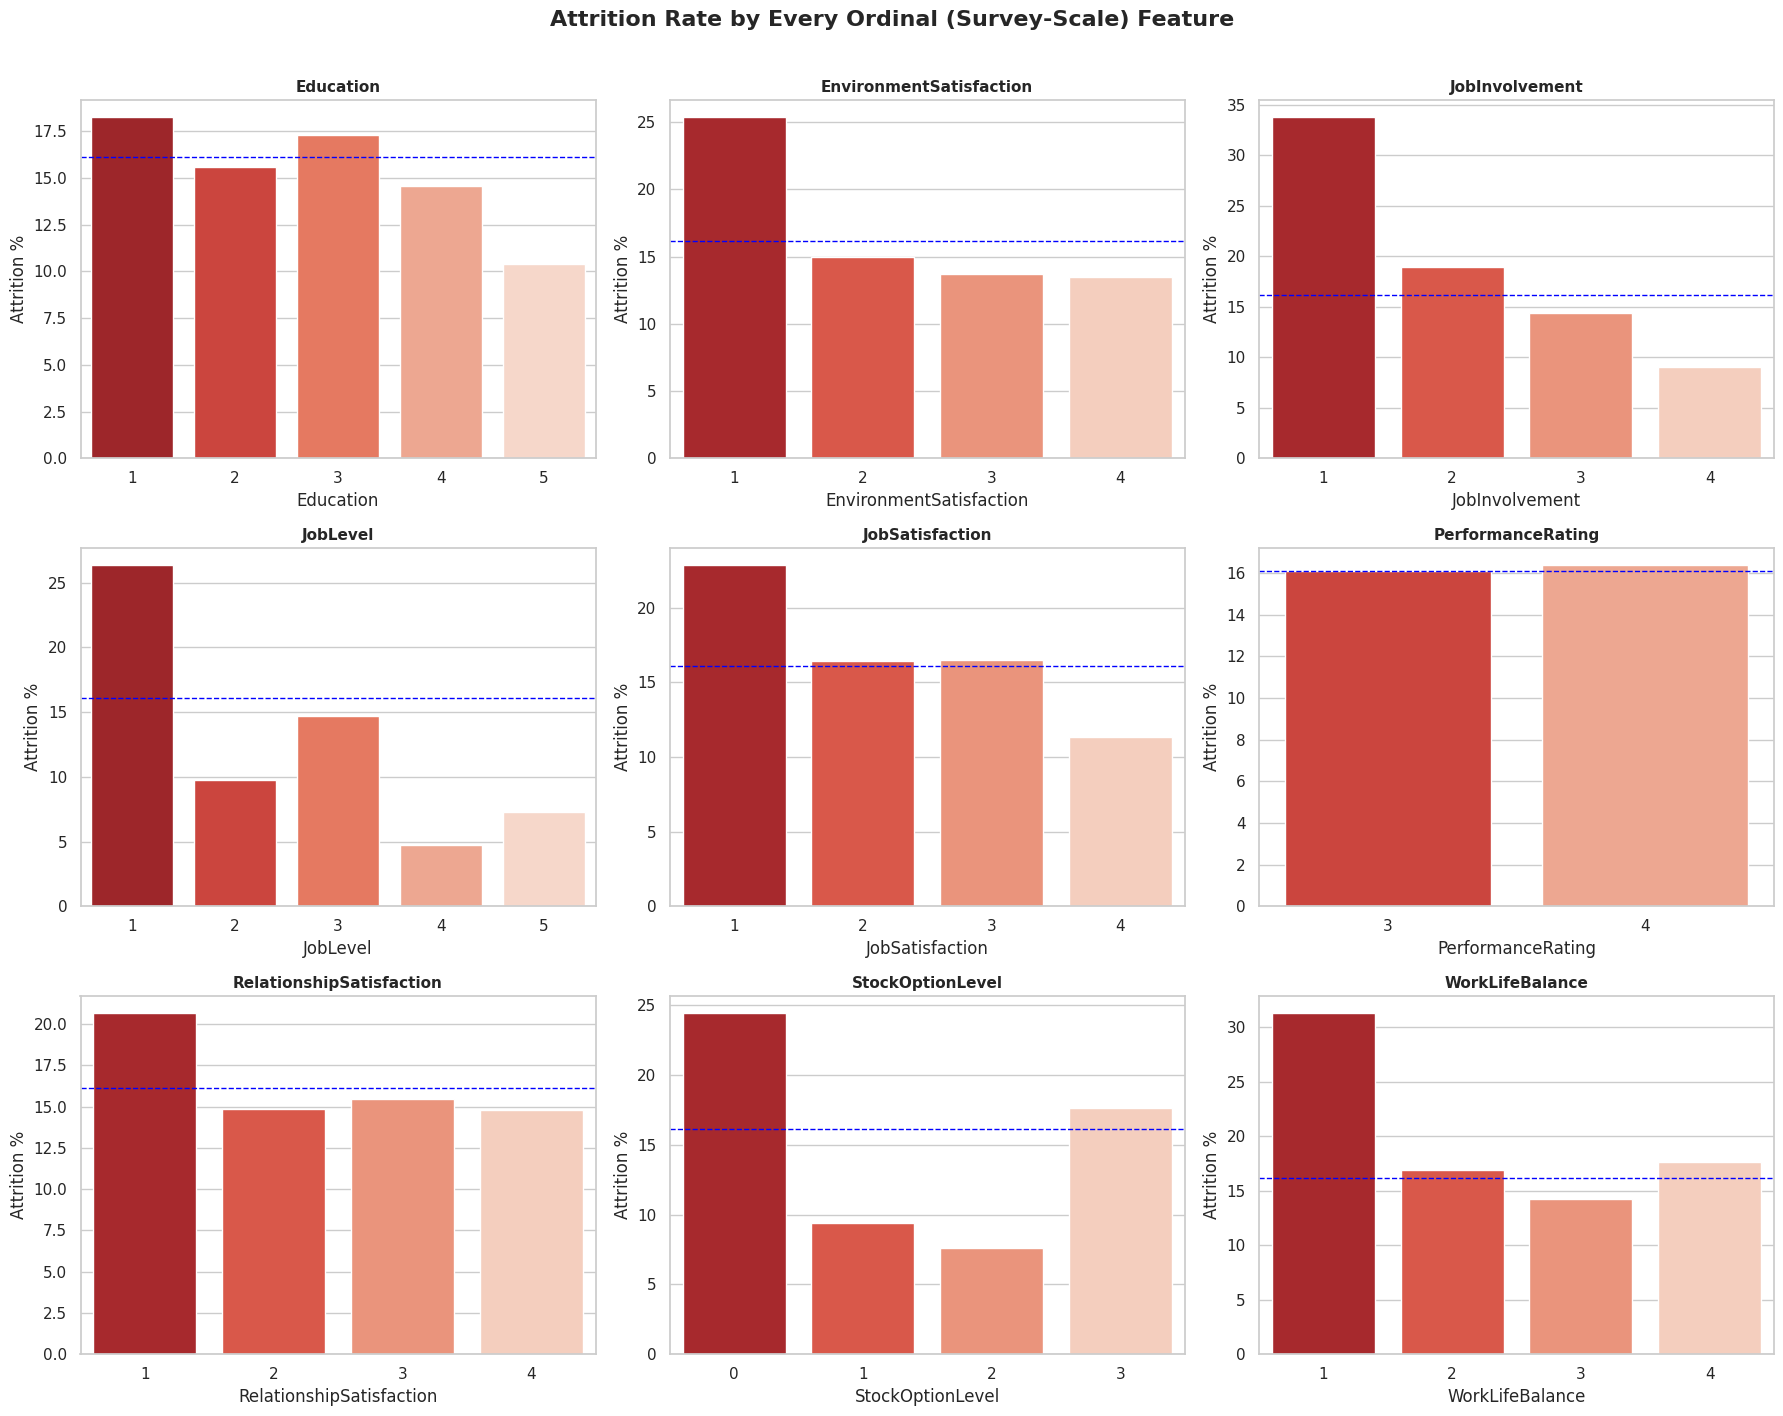

In [14]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(ORDINAL):
    ax = axes[i]
    rate = df.groupby(col)['Attrition_Flag'].mean().mul(100).round(2)
    sns.barplot(x=rate.index.astype(str), y=rate.values, ax=ax, hue=rate.index.astype(str),
                legend=False, palette='Reds_r')
    ax.axhline(baseline, color='blue', linestyle='--', linewidth=1)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_ylabel('Attrition %')

fig.suptitle('Attrition Rate by Every Ordinal (Survey-Scale) Feature', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Insight — ordinal drivers:** `JobSatisfaction`, `EnvironmentSatisfaction`, and `WorkLifeBalance` all show a clean monotonic decline in attrition as the score rises from 1→4, confirming they are genuine, actionable drivers. `StockOptionLevel = 0` attrits noticeably more than levels 1–3, supporting equity/stock options as a retention tool. `PerformanceRating`, as noted earlier, only has two values and shows almost no discriminating power.

### Highest-risk job roles specifically

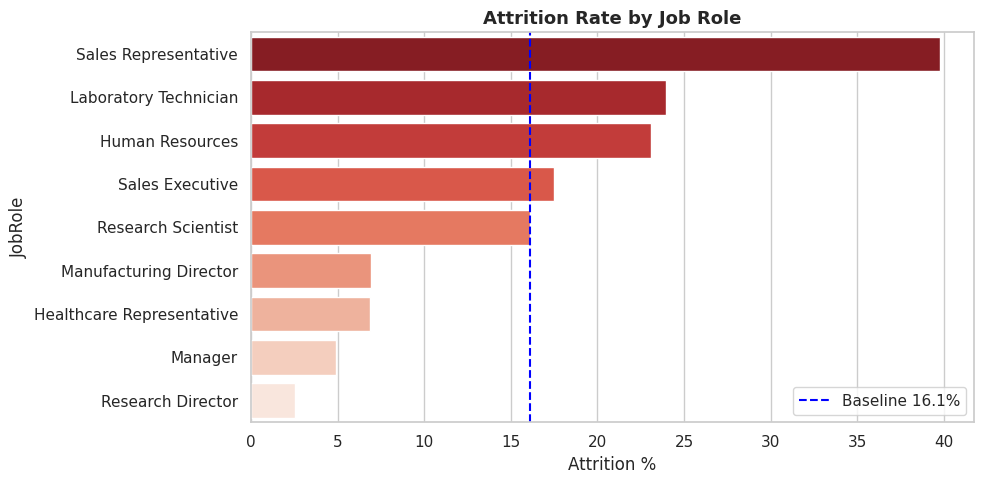

JobRole
Sales Representative         39.76
Laboratory Technician        23.94
Human Resources              23.08
Sales Executive              17.48
Research Scientist           16.10
Manufacturing Director        6.90
Healthcare Representative     6.87
Manager                       4.90
Research Director             2.50
Name: Attrition_Flag, dtype: float64

In [15]:
role_rate = attrition_rate_by('JobRole')
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=role_rate.values, y=role_rate.index, hue=role_rate.index, legend=False, palette='Reds_r', ax=ax)
ax.axvline(baseline, color='blue', linestyle='--', label=f'Baseline {baseline:.1f}%')
ax.set_xlabel('Attrition %')
ax.set_title('Attrition Rate by Job Role', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()
role_rate

**Insight:** **Sales Representative (~39.8%)** and **Laboratory Technician (~23.9%)** are far above every other role — Sales Representative alone is nearly 2.5x the company baseline and is the single highest-risk role in the organization.

## 7. Attrition vs. Every Continuous Feature

Side-by-side boxplots (Stayed vs. Left) for all 14 continuous features, to see which numeric variables actually separate the two groups and which don't.

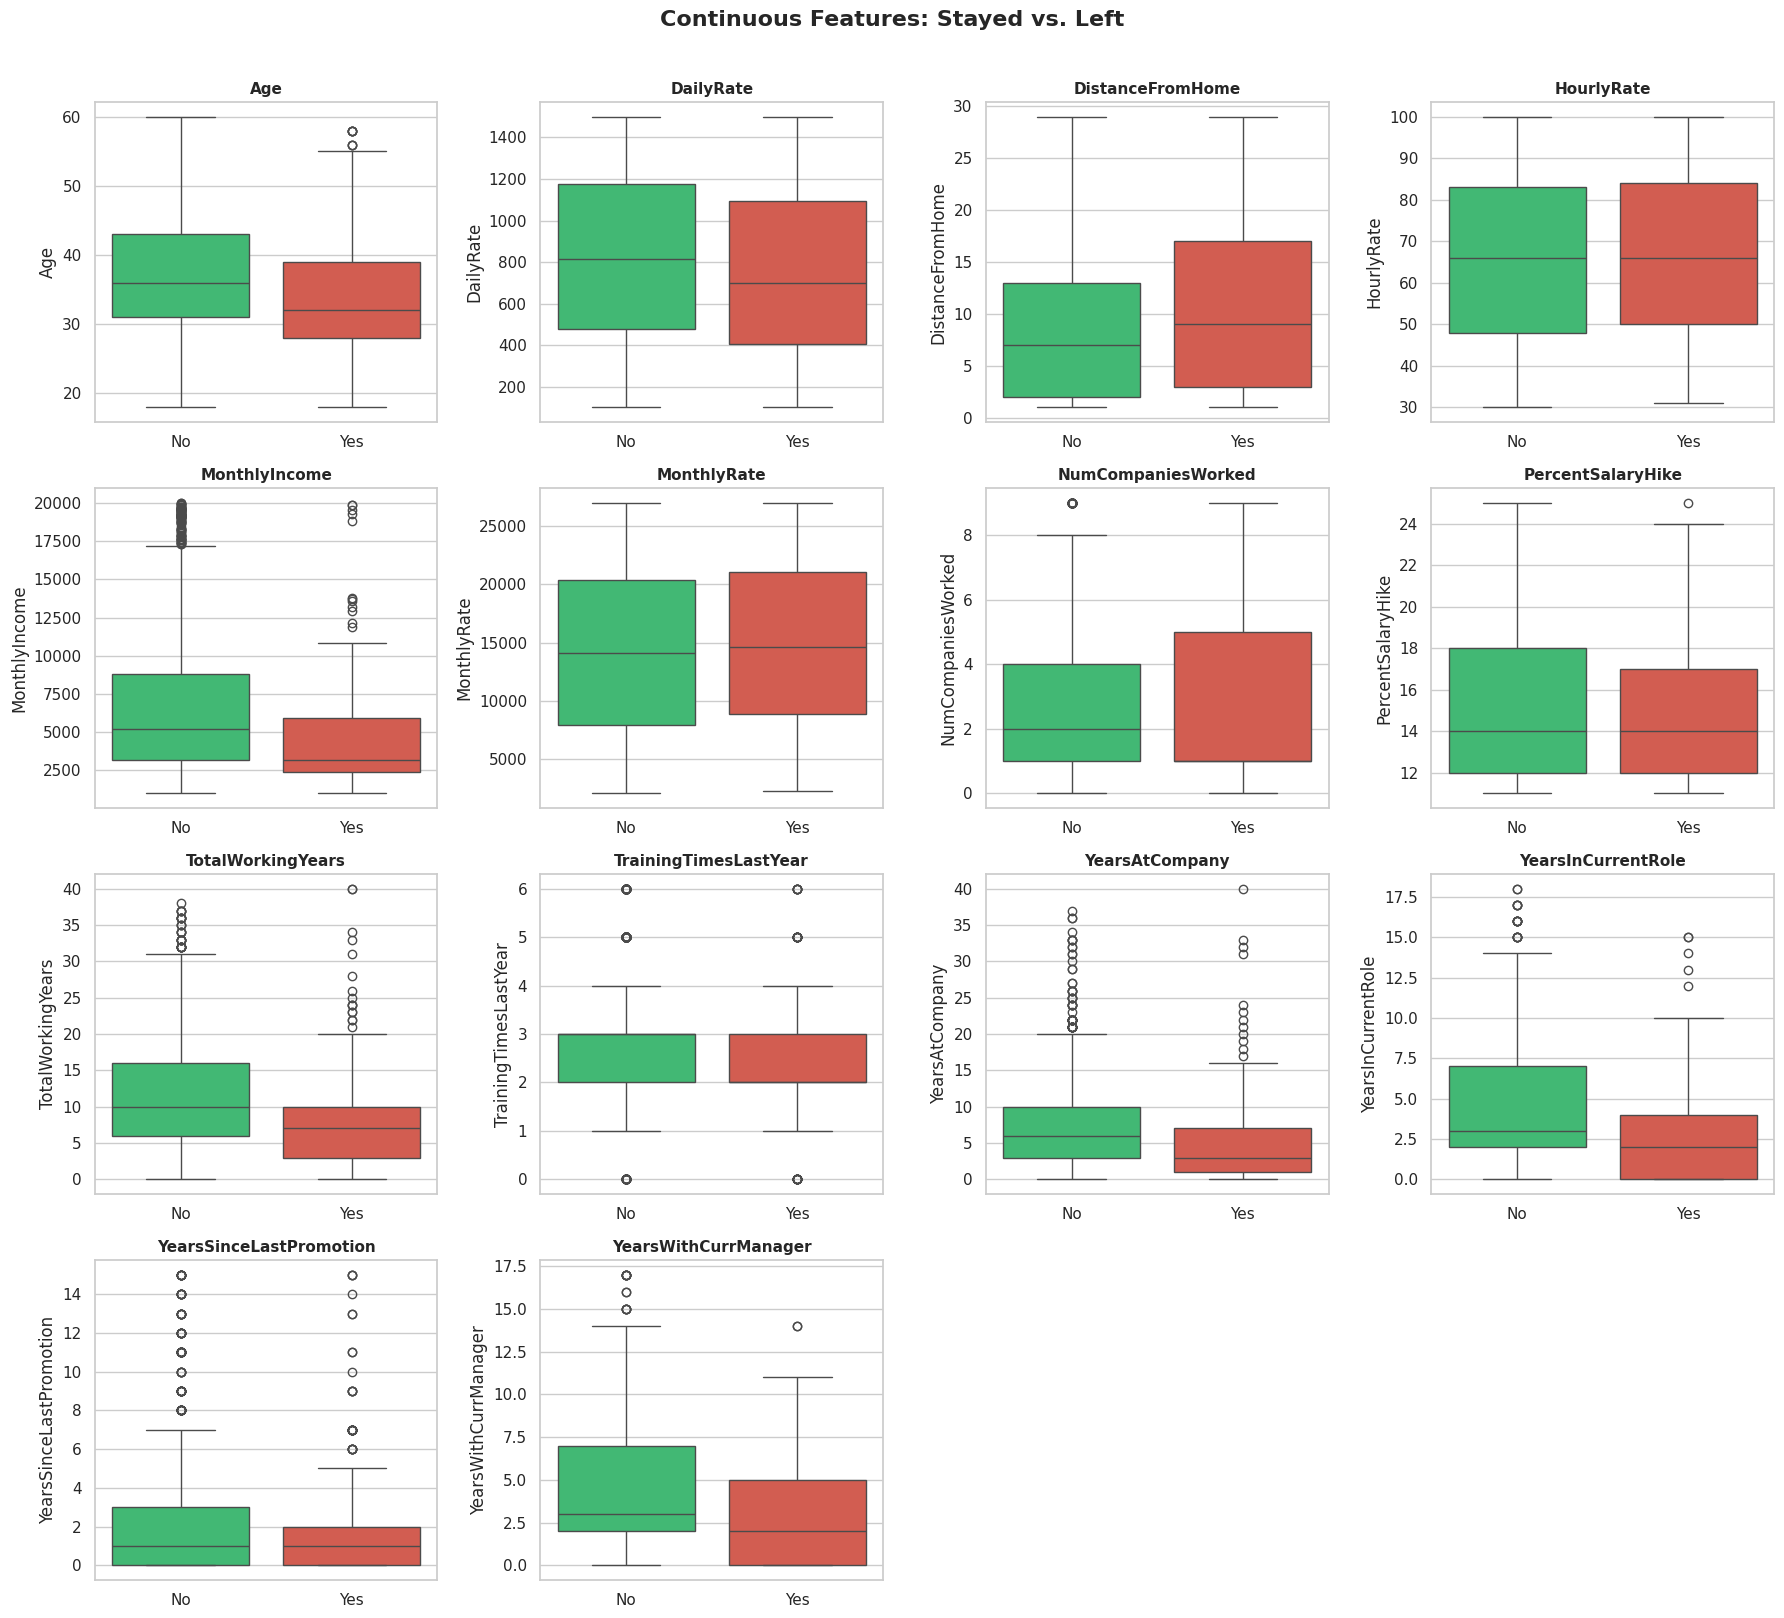

In [16]:
fig, axes = plt.subplots(4, 4, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(CONTINUOUS):
    ax = axes[i]
    sns.boxplot(data=df, x='Attrition', y=col, ax=ax, hue='Attrition', legend=False,
                palette={'No': '#2ecc71', 'Yes': '#e74c3c'}, order=['No', 'Yes'])
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('')

for j in range(len(CONTINUOUS), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Continuous Features: Stayed vs. Left', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Insight:** `TotalWorkingYears`, `YearsAtCompany`, `YearsInCurrentRole`, `YearsWithCurrManager`, `MonthlyIncome`, and `Age` all show a visibly lower median for the "Left" group — these are the continuous features that genuinely separate leavers from stayers. `DailyRate`, `HourlyRate`, `MonthlyRate`, and `PercentSalaryHike` show almost no separation between the two boxes — despite sounding pay-related, they don't meaningfully predict attrition on their own (only `MonthlyIncome` does).

In [17]:
t_test_results = []
for col in CONTINUOUS:
    left = df.loc[df['Attrition'] == 'Yes', col]
    stayed = df.loc[df['Attrition'] == 'No', col]
    t_stat, p_val = stats.ttest_ind(left, stayed, equal_var=False)
    t_test_results.append({'Feature': col, 'Mean (Left)': left.mean().round(1),
                            'Mean (Stayed)': stayed.mean().round(1),
                            't-statistic': round(t_stat, 2), 'p-value': round(p_val, 4)})

t_test_df = pd.DataFrame(t_test_results).sort_values('p-value')
t_test_df

,Feature,Mean (Left),Mean (Stayed),t-statistic,p-value
0,Age,33.6,37.6,-5.83,0.0000
4,MonthlyIncome,4787.1,6832.7,-7.48,0.0000
10,YearsAtCompany,5.1,7.4,-5.28,0.0000
8,TotalWorkingYears,8.2,11.9,-7.02,0.0000
13,YearsWithCurrManager,2.9,4.4,-6.63,0.0000
11,YearsInCurrentRole,2.9,4.5,-6.85,0.0000
2,DistanceFromHome,10.6,8.9,2.89,0.0041
9,TrainingTimesLastYear,2.6,2.8,-2.33,0.0204
1,DailyRate,750.4,812.5,-2.18,0.0300
6,NumCompaniesWorked,2.9,2.6,1.57,0.1163


**Insight:** Welch's t-test confirms the visual read numerically — `TotalWorkingYears`, `YearsInCurrentRole`, `Age`, `MonthlyIncome`, `YearsWithCurrManager`, and `YearsAtCompany` all show p-values far below 0.05, meaning the difference between "Left" and "Stayed" for these features is statistically significant, not random noise. `MonthlyRate`, `PercentSalaryHike`, `PerformanceRating`, and `HourlyRate` show p-values well above 0.05 — statistically no real difference between the two groups.

## 8. Correlation Structure

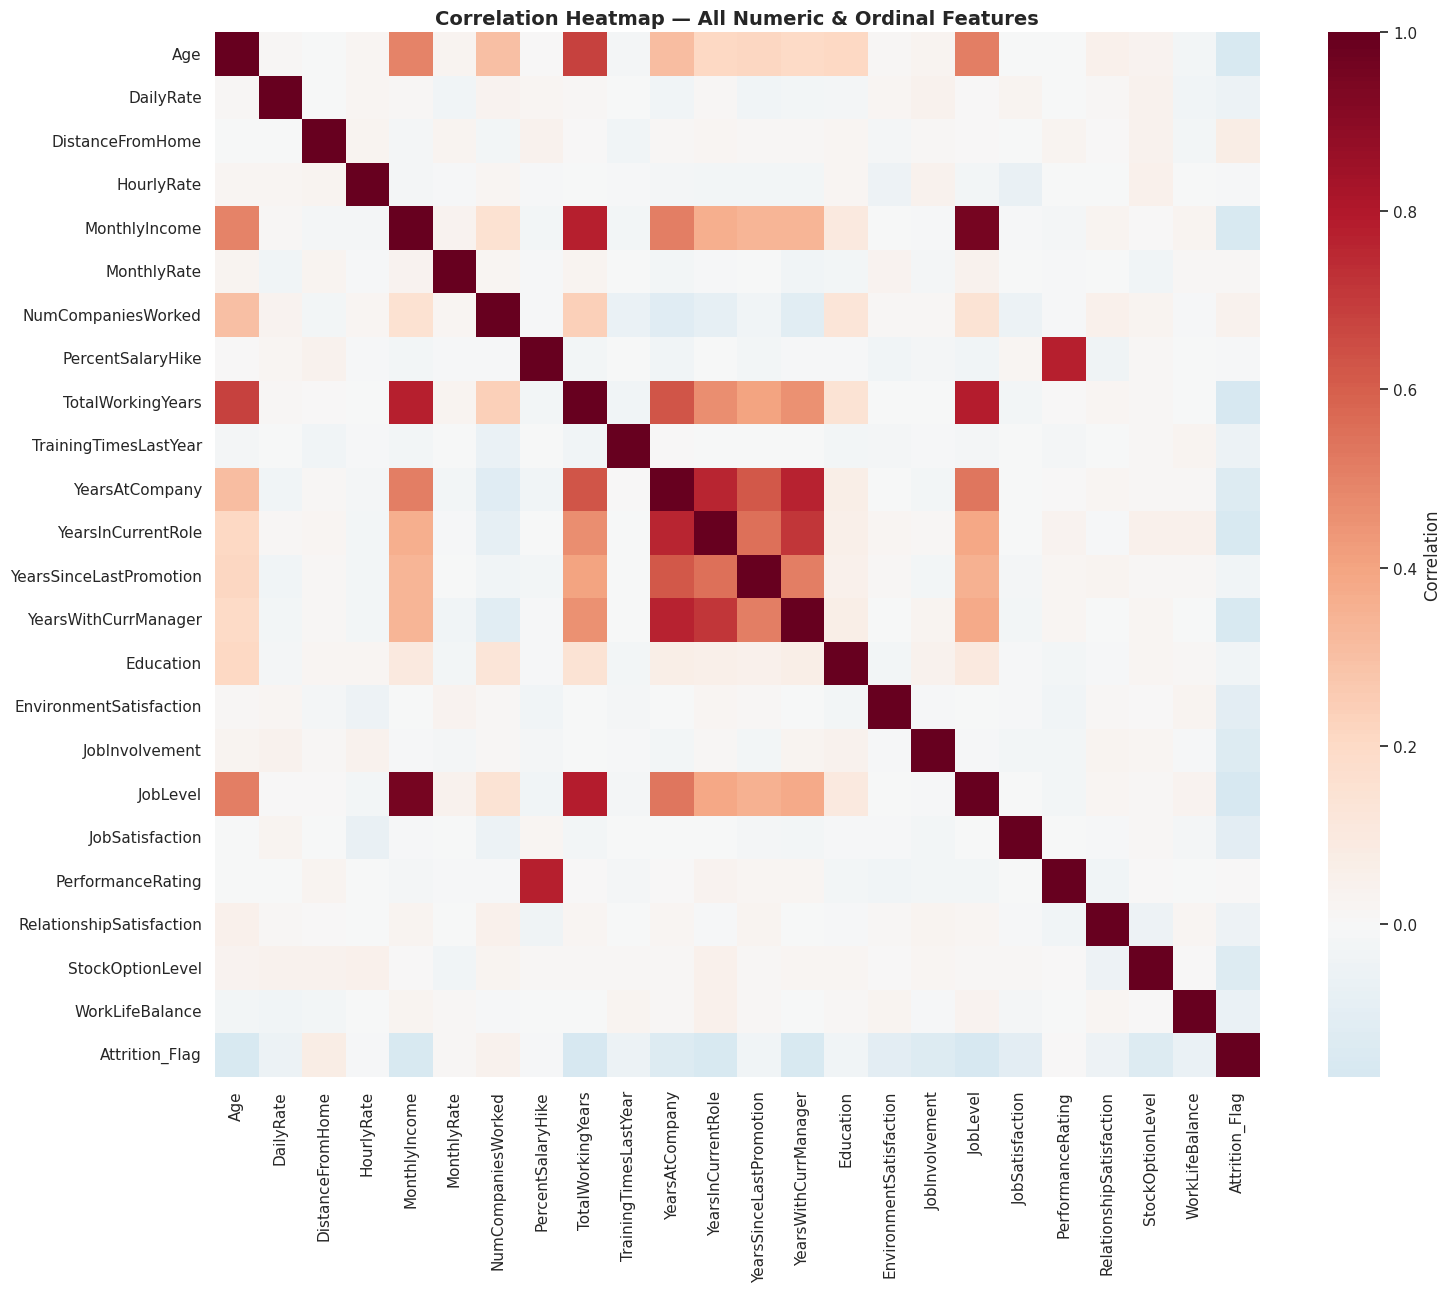

In [18]:
all_numeric = CONTINUOUS + ORDINAL + ['Attrition_Flag']
corr_matrix = df[all_numeric].corr()

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(corr_matrix, cmap='RdBu_r', center=0, annot=False, square=True,
            cbar_kws={'label': 'Correlation'}, ax=ax)
ax.set_title('Correlation Heatmap — All Numeric & Ordinal Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [19]:
attrition_corr = corr_matrix['Attrition_Flag'].drop('Attrition_Flag').sort_values(key=abs, ascending=False)
attrition_corr.to_frame('Correlation with Attrition')

,Correlation with Attrition
TotalWorkingYears,-0.171063
JobLevel,-0.169105
YearsInCurrentRole,-0.160545
MonthlyIncome,-0.159840
Age,-0.159205
YearsWithCurrManager,-0.156199
StockOptionLevel,-0.137145
YearsAtCompany,-0.134392
JobInvolvement,-0.130016
JobSatisfaction,-0.103481


**Insight:** Ranked by absolute correlation, `TotalWorkingYears`, `JobLevel`, `YearsInCurrentRole`, `MonthlyIncome`, and `Age` are the strongest negative correlates (seniority/experience/pay reduce attrition risk), while `NumCompaniesWorked` and `DistanceFromHome` are the strongest (weaker) positive correlates. No pair among the predictors shows dangerous multicollinearity (nothing above ~0.8 besides the expected tenure-cluster: `YearsAtCompany` / `YearsInCurrentRole` / `YearsWithCurrManager` naturally move together).

## 9. Multivariate Deep Dives

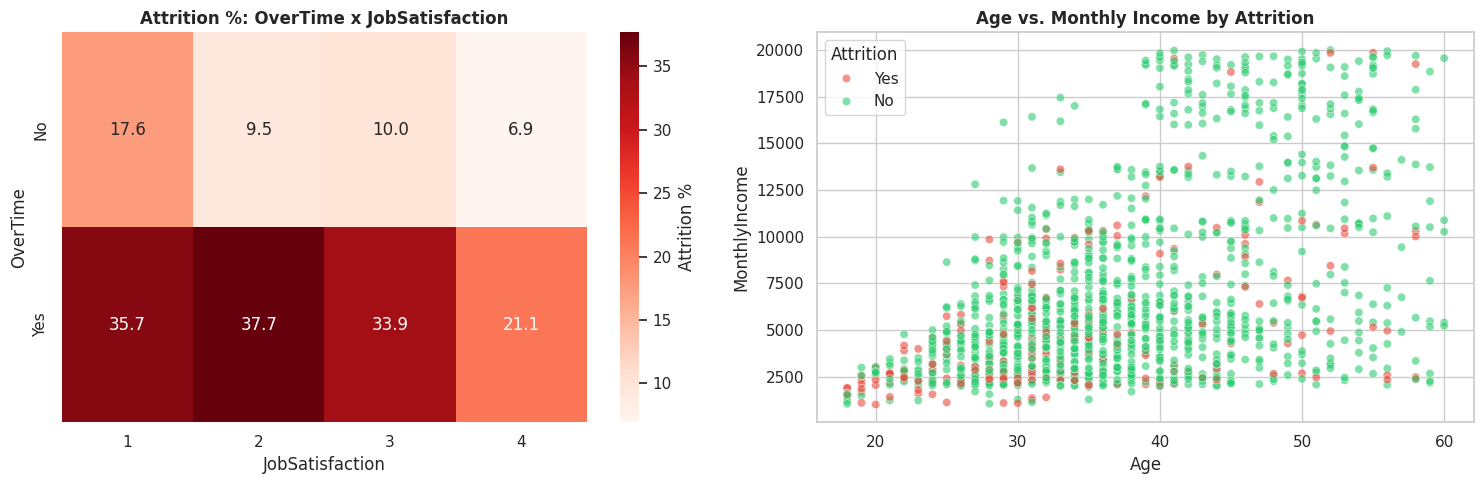

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

pivot = df.pivot_table(values='Attrition_Flag', index='OverTime', columns='JobSatisfaction', aggfunc='mean') * 100
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='Reds', ax=axes[0], cbar_kws={'label': 'Attrition %'})
axes[0].set_title('Attrition %: OverTime x JobSatisfaction', fontweight='bold')

sns.scatterplot(data=df, x='Age', y='MonthlyIncome', hue='Attrition',
                 palette={'No': '#2ecc71', 'Yes': '#e74c3c'}, alpha=0.6, ax=axes[1])
axes[1].set_title('Age vs. Monthly Income by Attrition', fontweight='bold')

plt.tight_layout()
plt.show()

**Insight:** OverTime + low JobSatisfaction compound each other — this combination is the single highest-attrition segment in the whole dataset, well above either factor alone. The scatter plot shows attrition (red) concentrated in the young + low-income corner; high earners rarely leave regardless of age.

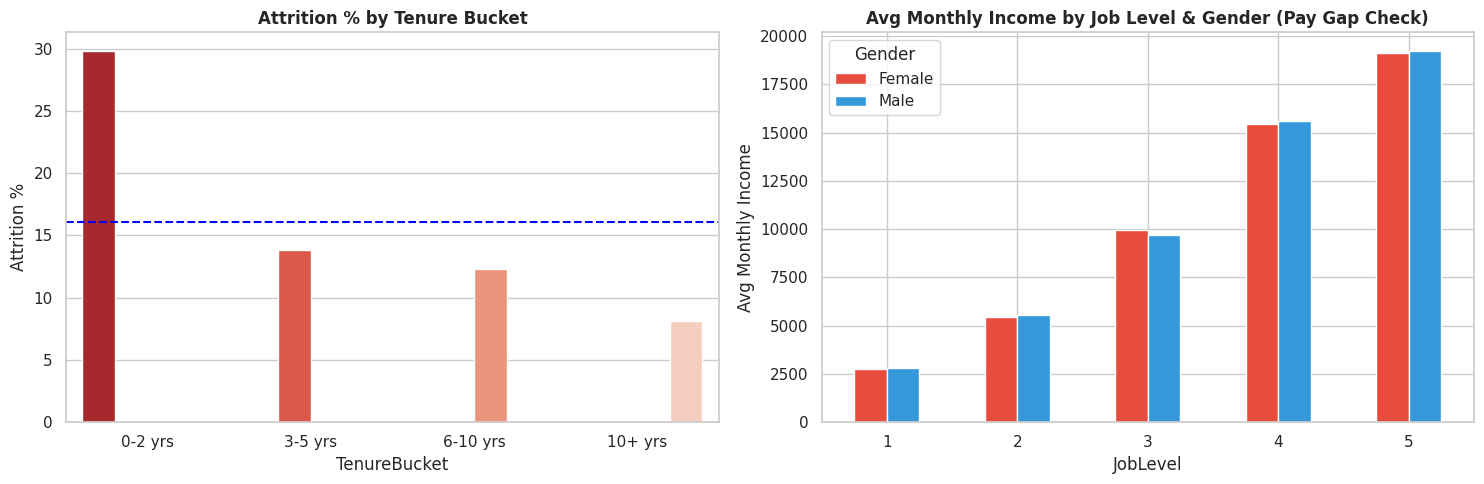

In [21]:
df['TenureBucket'] = pd.cut(df['YearsAtCompany'], bins=[-1, 2, 5, 10, 40],
                             labels=['0-2 yrs', '3-5 yrs', '6-10 yrs', '10+ yrs'])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

tenure_rate = df.groupby('TenureBucket', observed=True)['Attrition_Flag'].mean() * 100
sns.barplot(x=tenure_rate.index, y=tenure_rate.values, hue=tenure_rate.index, legend=False,
            palette='Reds_r', ax=axes[0])
axes[0].axhline(baseline, color='blue', linestyle='--')
axes[0].set_title('Attrition % by Tenure Bucket', fontweight='bold')
axes[0].set_ylabel('Attrition %')

gender_income = df.groupby(['Gender', 'JobLevel'], observed=True)['MonthlyIncome'].mean().unstack('Gender')
gender_income.plot(kind='bar', ax=axes[1], color=['#e74c3c', '#3498db'])
axes[1].set_title('Avg Monthly Income by Job Level & Gender (Pay Gap Check)', fontweight='bold')
axes[1].set_ylabel('Avg Monthly Income')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

**Insight:** Attrition risk is front-loaded — nearly double the baseline in the first 2 years, then drops sharply. The gender pay-gap check by job level shows income is driven by **level**, not gender — male and female average pay tracks closely within each job level, no systematic gap visible in this dataset.

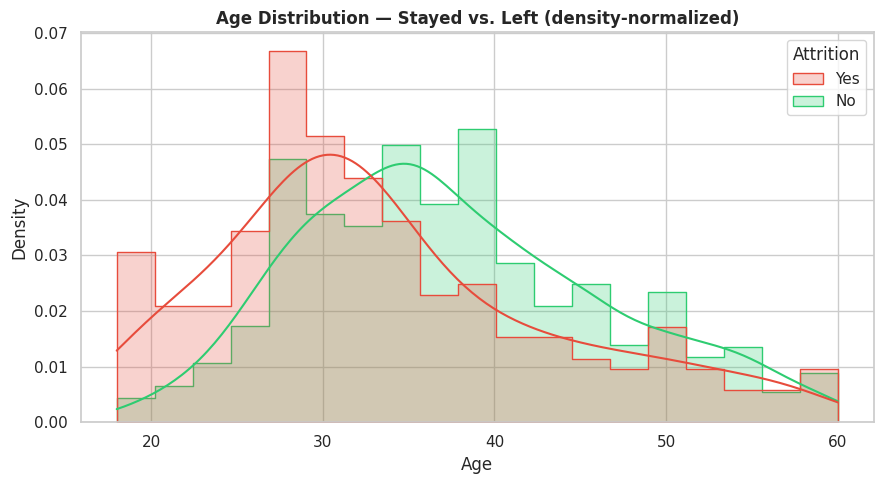

In [22]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(data=df, x='Age', hue='Attrition', kde=True, element='step',
             palette={'No': '#2ecc71', 'Yes': '#e74c3c'}, stat='density', common_norm=False, ax=ax)
ax.set_title('Age Distribution — Stayed vs. Left (density-normalized)', fontweight='bold')
plt.tight_layout()
plt.show()

**Insight:** Density-normalizing (so the two groups are comparable despite very different sample sizes) makes it clear the 'Left' distribution peaks earlier and is more concentrated in the late-20s/early-30s than the broader, flatter 'Stayed' distribution — early-career employees are disproportionately the ones leaving.

## 10. Key Findings & Recommendations

**Statistical summary**
- Company-wide attrition baseline: **16.12%** (237/1,470).
- Dataset is fully clean (0 missing, 0 duplicates); 3 zero-variance and 1 ID column excluded from analysis.
- 6 continuous features show statistically significant separation (Welch's t-test, p < 0.05) between "Left" and "Stayed": `TotalWorkingYears`, `Age`, `MonthlyIncome`, `YearsAtCompany`, `YearsInCurrentRole`, `YearsWithCurrManager`.
- `MonthlyIncome`, `YearsSinceLastPromotion`, `YearsAtCompany`, and `TotalWorkingYears` are the most right-skewed features — median is the more representative summary statistic than mean for all four.

**Top attrition drivers (ranked)**
1. **OverTime = Yes** — ~3x the attrition rate of non-overtime employees; compounds further with low JobSatisfaction.
2. **Job role** — Sales Representative (~39.8%) and Laboratory Technician (~23.9%) are far above baseline.
3. **Tenure < 2 years** — new hires attrit at nearly double the baseline; risk drops sharply after year 3.
4. **Low satisfaction scores** (Job, Environment, Work-Life Balance) — each shows a clean monotonic decline in attrition as score improves.
5. **Lower income & younger age**, especially in combination.
6. **Marital status (Single)** and **frequent business travel** — secondary but consistent risk factors.

**Weak / non-drivers** (worth knowing so effort isn't wasted here): `PerformanceRating` (only 2 distinct values in the data), `Gender`, `DailyRate`/`HourlyRate`/`MonthlyRate`, `PercentSalaryHike`, `EducationField`. No meaningful gender pay gap detected by job level.

**Recommended actions for HR**
1. Audit and reduce overtime load, starting with Sales Representatives and Laboratory Technicians.
2. Build a structured 0–24 month onboarding/retention program — this is the highest-risk tenure window.
3. Review junior-level compensation bands, since low income concentrates with young age and higher attrition.
4. Expand stock option eligibility at Level 0, where attrition is highest among equity tiers.
